## Business Decision-Making: Trial of Delivery Robot

### Imports + Load data + Reshape

In [262]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load robot data
robots_raw = pd.read_csv("Robot_Info.csv")

# Transform data: set index and transpose
robots = robots_raw.set_index("Robot_Prototype").T
robots.index.name = "Prototype"

# Convert all data to numeric
robots = robots.apply(pd.to_numeric)

robots.head(7)


Robot_Prototype,Carrying Capacity,Battery Size,Speed,Mobility,Aesthetic,Cost Per Unit,Reliability
Prototype,,,,,,,
Alpha,35,11,15,5,10,10000,15
Bravo,50,6,15,4,6,4500,24
Charlie,50,9,15,3,6,6250,24
Delta,40,12,25,4,3,8000,33
Echo,55,10,15,2,6,5500,30
Foxtrot,70,9,15,1,7,7500,30
Gamma,55,10,18,3,9,5000,35


### Normalisation (0–1) with benefit vs cost criteria

Since the criteria are measured on different scales, the data is normalised to a 0–1 range. In the code below, bnefit criteria are scaled so that higher values indicate better performance, while cost criteria are reversed so that lower values receive higher scores.

In [263]:
# Normalisation of criteria
benefit = ["Carrying Capacity", "Battery Size", "Speed", "Mobility", "Aesthetic", "Reliability"]
cost = ["Cost Per Unit"]

# Create a copy for normalisation
norm = robots.copy().astype(float)

# Benefit criteria: higher is better (standard scale)
for c in benefit:
    d = norm[c].max() - norm[c].min()
    norm[c] = 1.0 if d == 0 else (norm[c] - norm[c].min()) / d

# Cost criteria: lower is better (reverse scale)
for c in cost:
    d = norm[c].max() - norm[c].min()
    norm[c] = 1.0 if d == 0 else (norm[c].max() - norm[c]) / d

norm.head(7)


Robot_Prototype,Carrying Capacity,Battery Size,Speed,Mobility,Aesthetic,Cost Per Unit,Reliability
Prototype,,,,,,,
Alpha,0.000000,0.833333,0.0,1.00,1.000000,0.000000,0.00
Bravo,0.428571,0.000000,0.0,0.75,0.428571,1.000000,0.45
Charlie,0.428571,0.500000,0.0,0.50,0.428571,0.681818,0.45
Delta,0.142857,1.000000,1.0,0.75,0.000000,0.363636,0.90
Echo,0.571429,0.666667,0.0,0.25,0.428571,0.818182,0.75
Foxtrot,1.000000,0.500000,0.0,0.00,0.571429,0.454545,0.75
Gamma,0.571429,0.666667,0.3,0.50,0.857143,0.909091,1.00


### Plan 1 (Management weights) using Weighted Sum Model

For Plan 1, weights are assigned based on management priorities, where carrying capacity and cost are the most important factors. These weights reflect the business objective of operating at scale and maximising large deliveries. The weighted sum method is then used to calculate an overall score for each robot.

In [264]:
# rankings for Plan 1 weights
w1 = pd.Series({
    "Carrying Capacity": 7,   # most important
    "Cost Per Unit": 6,       # second
    "Battery Size": 4,        # > reliability
    "Reliability": 3,
    "Speed": 2,               # = mobility
    "Mobility": 2,
    "Aesthetic": 1            # least important
}, dtype=float)

# Normalize weights to sum to 1
w1 = w1 / w1.sum()

print("\nPlan 1 weights:")
display(w1.sort_values(ascending=False).to_frame("Weight").round(4))

# Calculate scores and rankings
score1 = (norm * w1).sum(axis=1).sort_values(ascending=False)


# Display Plan 1 results
plan1 = score1.to_frame("Plan1_Score")
plan1["Plan1_Rank"] = plan1["Plan1_Score"].rank(ascending=False, method="dense").astype(int)

# Identify best plan
best_plan1 = score1.index[0]


print("PLAN 1 ranking:")
display(plan1.sort_values("Plan1_Rank").round(4))
print("Plan 1 winner:", best_plan1)



Plan 1 weights:


,Weight
Carrying Capacity,0.28
Cost Per Unit,0.24
Battery Size,0.16
Reliability,0.12
Speed,0.08
Mobility,0.08
Aesthetic,0.04


PLAN 1 ranking:


,Plan1_Score,Plan1_Rank
Prototype,,
Gamma,0.7031,1
Echo,0.5902,2
Foxtrot,0.5819,3
Delta,0.5353,4
Bravo,0.4911,5
Charlie,0.4748,6
Alpha,0.2533,7


Plan 1 winner: Gamma


### PLAN 2 — AHP weights (technology-selling strategy)

For Plan 2, the Analytic Hierarchy Process (AHP) is used to derive criterion weights. Pairwise comparisons reflect the importance of battery size, cost, and reliability, which represent the key sources of intellectual property value. The resulting weights are then applied using the weighted sum model.

In [ ]:

# Battery, Cost, Reliability are most important (as required)

# list of criteria
criteria_order = [
    "Battery Size",
    "Cost Per Unit",
    "Reliability",
    "Carrying Capacity",
    "Speed",
    "Mobility",
    "Aesthetic"
]

# Pairwise comparison matrix for AHP, 1-9 scale (1=equal importance, 9=extreme importance, reciprocals for less important)
A = np.array([
    [1,   1,   2,   5,   7,   7,   9],      # Battery
    [1,   1,   2,   5,   7,   7,   9],      # Cost
    [1/2, 1/2, 1,   4,   6,   6,   8],      # Reliability
    [1/5, 1/5, 1/4, 1,   3,   3,   5],      # Capacity
    [1/7, 1/7, 1/6, 1/3, 1,   1,   3],      # Speed
    [1/7, 1/7, 1/6, 1/3, 1,   1,   3],      # Mobility
    [1/9, 1/9, 1/8, 1/5, 1/3, 1/3, 1]       # Aesthetic
], dtype=float)

# Normalize columns and compute average to get weights
A_norm = A / A.sum(axis=0)
w2_vals = A_norm.mean(axis=1)

# Create Series for weights
w2 = pd.Series(w2_vals, index=criteria_order)
w2 = w2 / w2.sum()

# Reindex to match norm columns
w2 = w2.reindex(norm.columns)

print("\nPlan 2 AHP weights:")
display(w2.sort_values(ascending=False).to_frame("Weight").round(4))




score2 = (norm * w2).sum(axis=1).sort_values(ascending=False)

plan2 = score2.to_frame("Plan2_Score")
plan2["Plan2_Rank"] = plan2["Plan2_Score"].rank(ascending=False, method="dense").astype(int)

print("\nPLAN 2 ranking:")
display(plan2.sort_values("Plan2_Rank").round(4))


Plan 2 AHP weights:


,Weight
Robot_Prototype,
Battery Size,0.3001
Cost Per Unit,0.3001
Reliability,0.2049
Carrying Capacity,0.0863
Speed,0.0429
Mobility,0.0429
Aesthetic,0.0227



PLAN 2 ranking:


,Plan2_Score,Plan2_Rank
Prototype,,
Gamma,0.7809,1
Delta,0.6811,2
Echo,0.6691,3
Foxtrot,0.5395,4
Charlie,0.5151,5
Bravo,0.4712,6
Alpha,0.3157,7


### Final selection rule: choose 2 different prototypes (Plan 1 + Plan 2)

In [266]:
# Identify best plan for Plan 2
best_plan2 = score2.index[0]
if best_plan2 == best_plan1:
    best_plan2 = score2.index[1]

print("\nFINAL TWO PROTOTYPES FOR TRIAL:")
print("Plan 1:", best_plan1)
print("Plan 2:", best_plan2)



FINAL TWO PROTOTYPES FOR TRIAL:
Plan 1: Gamma
Plan 2: Delta


### Combined summary table

In [267]:
# Summary of both plans
summary = pd.DataFrame({
    "Plan1_Score": (norm * w1).sum(axis=1),
    "Plan2_Score": (norm * w2).sum(axis=1),
})

summary["Plan1_Rank"] = summary["Plan1_Score"].rank(ascending=False, method="dense").astype(int)
summary["Plan2_Rank"] = summary["Plan2_Score"].rank(ascending=False, method="dense").astype(int)

display(summary.sort_values("Plan1_Rank").round(4))

,Plan1_Score,Plan2_Score,Plan1_Rank,Plan2_Rank
Prototype,,,,
Gamma,0.7031,0.7809,1,1
Echo,0.5902,0.6691,2,3
Foxtrot,0.5819,0.5395,3,4
Delta,0.5353,0.6811,4,2
Bravo,0.4911,0.4712,5,6
Charlie,0.4748,0.5151,6,5
Alpha,0.2533,0.3157,7,7


## Vizuals

#### Cost Per Unit Comparison

This bar chart compares the cost per unit across robot prototypes. Since cost is a minimisation criterion, lower bars indicate more cost-effective robots, supporting interpretation of the cost component in the decision model.

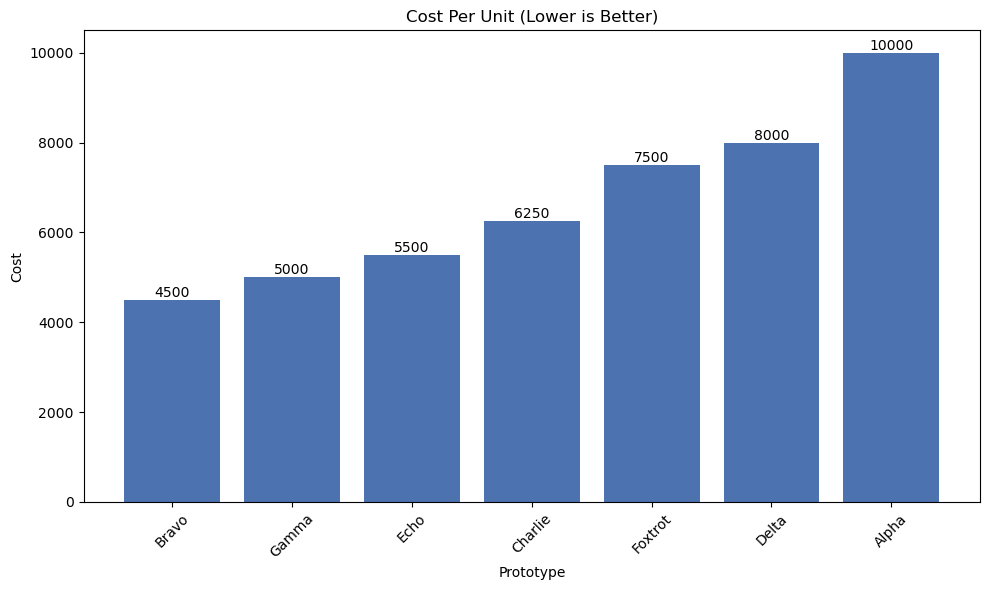

In [278]:
# Visualization of Cost Per Unit for all prototypes
cost_sorted = robots["Cost Per Unit"].sort_values()

plt.figure(figsize=(10, 6))
plt.bar(cost_sorted.index, cost_sorted.values, color="#4C72B0")

plt.title("Cost Per Unit (Lower is Better)")
plt.xlabel("Prototype")
plt.ylabel("Cost")
plt.xticks(rotation=45)

for i, v in enumerate(cost_sorted.values):
    plt.text(i, v, f"{int(v)}", ha="center", va="bottom")

plt.tight_layout()
plt.show()


#### Bar Chart for  raw criteria values for all prototypes

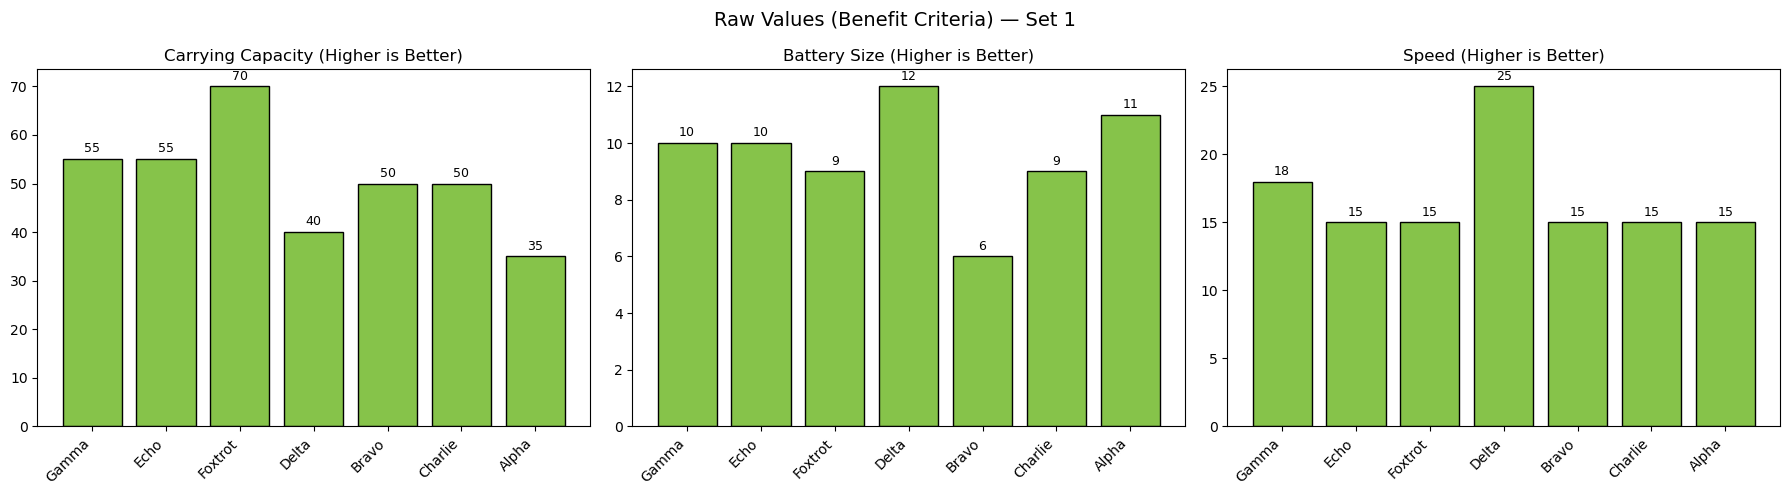

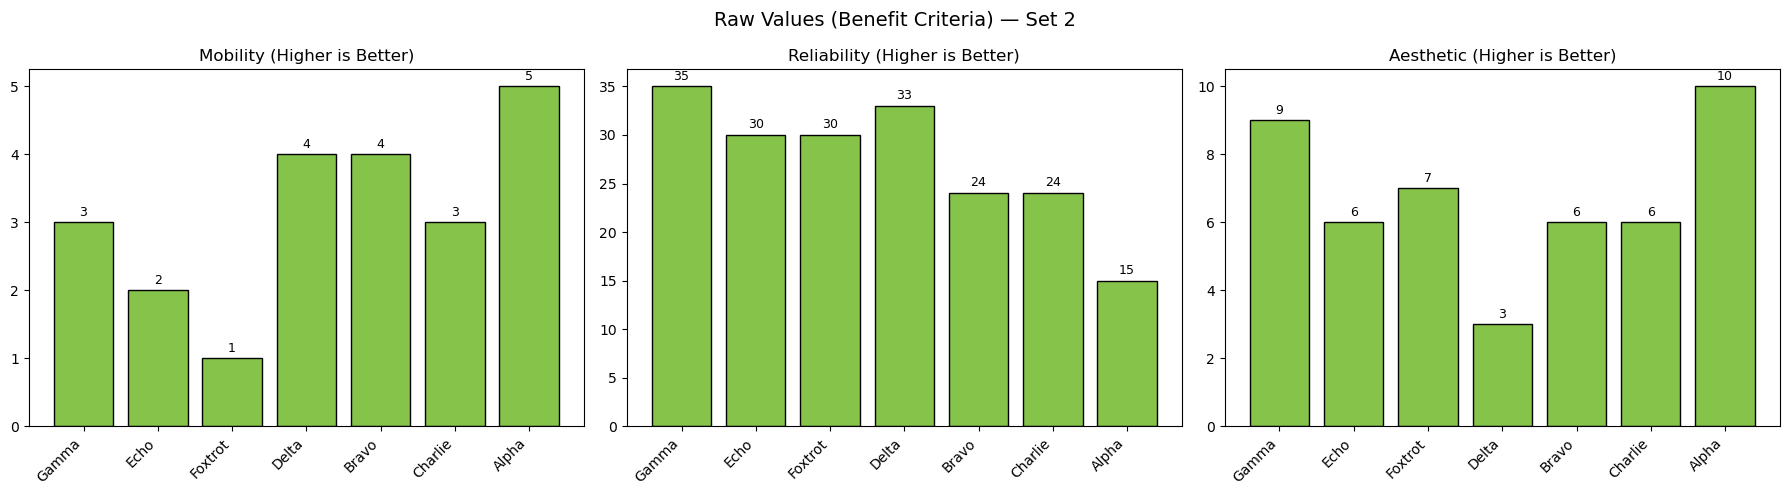

In [ ]:
# Visualization of raw criteria values for all prototypes
criteria_raw = [
    ("Carrying Capacity", "Carrying Capacity (Higher is Better)"),
    ("Battery Size", "Battery Size (Higher is Better)"),
    ("Speed", "Speed (Higher is Better)"),
    ("Mobility", "Mobility (Higher is Better)"),
    ("Reliability", "Reliability (Higher is Better)"),
    ("Aesthetic", "Aesthetic (Higher is Better)")
]

order = plan1.sort_values("Plan1_Rank").index

# Function to plot 3 criteria at a time
def plot_3(criteria_subset, main_title):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    for ax, (col, title) in zip(axes, criteria_subset):
        values = robots.loc[order, col]

        # GREEN bars
        ax.bar(order, values, color="#86C34A", edgecolor="black")

        ax.set_title(title)
        ax.set_xticks(range(len(order)))
        ax.set_xticklabels(order, rotation=45, ha="right")

        for i, v in enumerate(values):
            ax.text(i, v + 0.02 * values.max(), f"{v}", ha="center", fontsize=9)

    fig.suptitle(main_title, fontsize=14)
    plt.tight_layout()
    plt.show()

# First 3 criteria
plot_3(criteria_raw[:3], "Raw Values (Benefit Criteria) — Set 1")

# Last 3 criteria
plot_3(criteria_raw[3:], "Raw Values (Benefit Criteria) — Set 2")


#### Heatmap of Normalised Criteria (Sorted by managemnet priorities)

The heatmap shows the normalised performance of each robot across all criteria, ordered by the Plan 1 ranking. Darker cells indicate stronger relative performance, allowing quick comparison of strengths and weaknesses across robots.

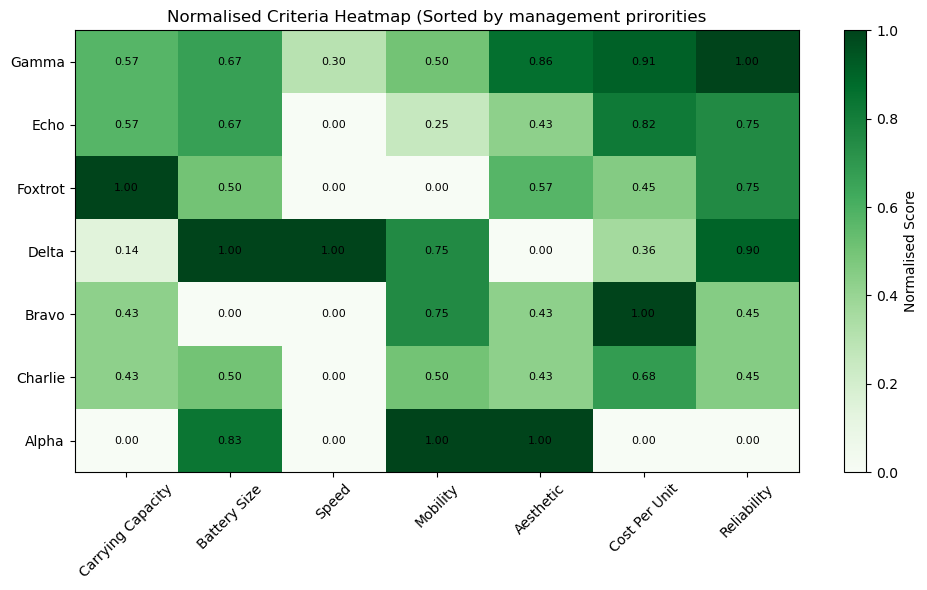

In [284]:
import matplotlib.pyplot as plt

# Sort rows by Plan 1 rank
norm_sorted = norm.loc[plan1.sort_values("Plan1_Rank").index]

plt.figure(figsize=(10, 6))

# Heatmap with single-hue colour scale
plt.imshow(
    norm_sorted,
    aspect="auto",
    cmap="Greens",
    vmin=0, vmax=1
)

plt.colorbar(label="Normalised Score")

# Axis labels
plt.xticks(range(len(norm.columns)), norm.columns, rotation=45)
plt.yticks(range(len(norm_sorted.index)), norm_sorted.index)

# Add values inside cells
for i in range(norm_sorted.shape[0]):
    for j in range(norm_sorted.shape[1]):
        plt.text(
            j, i,
            f"{norm_sorted.iloc[i, j]:.2f}",
            ha="center", va="center",
            fontsize=8,
            color="black"
        )

plt.title("Normalised Criteria Heatmap (Sorted by management prirorities")
plt.tight_layout()
plt.show()


#### Stacked Bar Chart – WSM Contributions by Criterion

This visual decomposes the weighted sum score for each robot by showing the contribution of each criterion. Each bar represents a robot, while the stacked segments illustrate how individual criteria combine to form the final score.

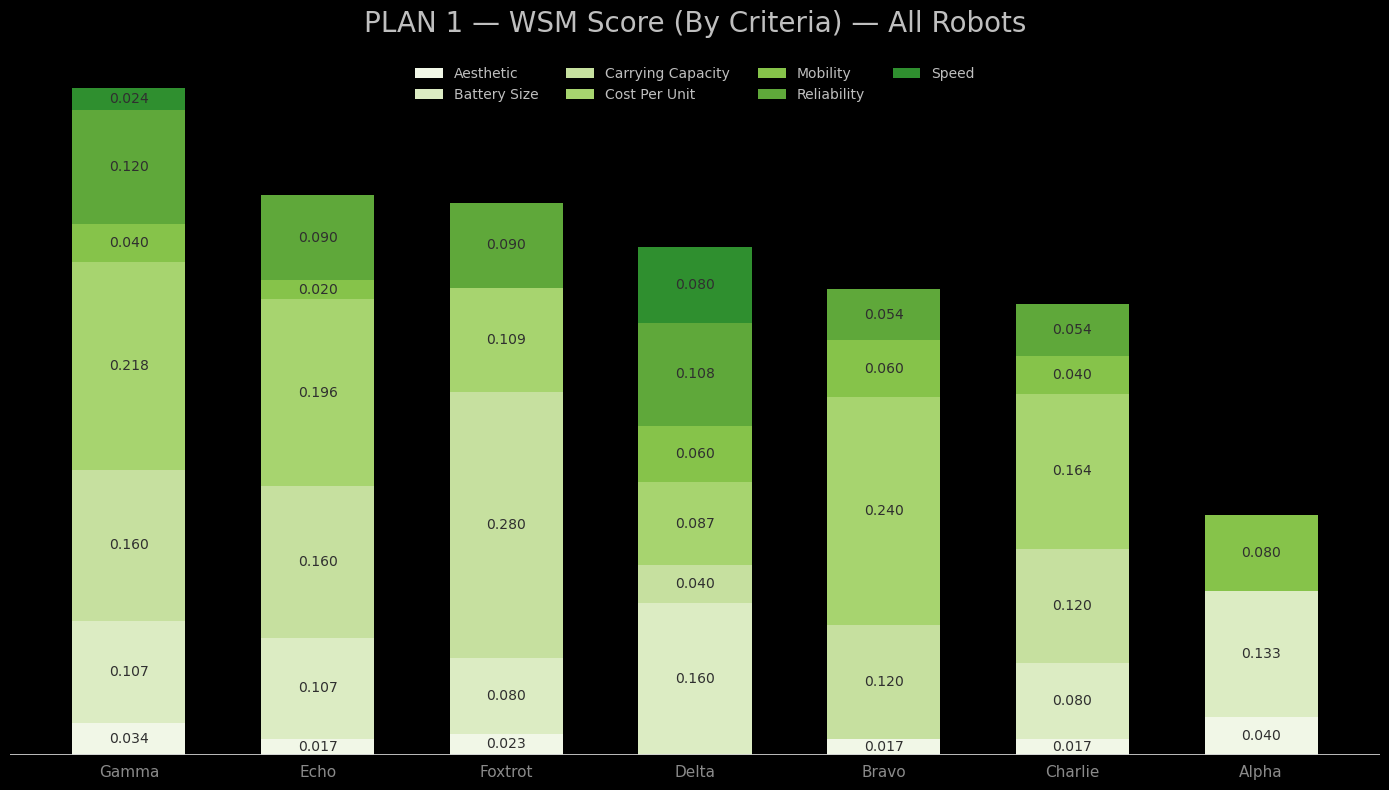

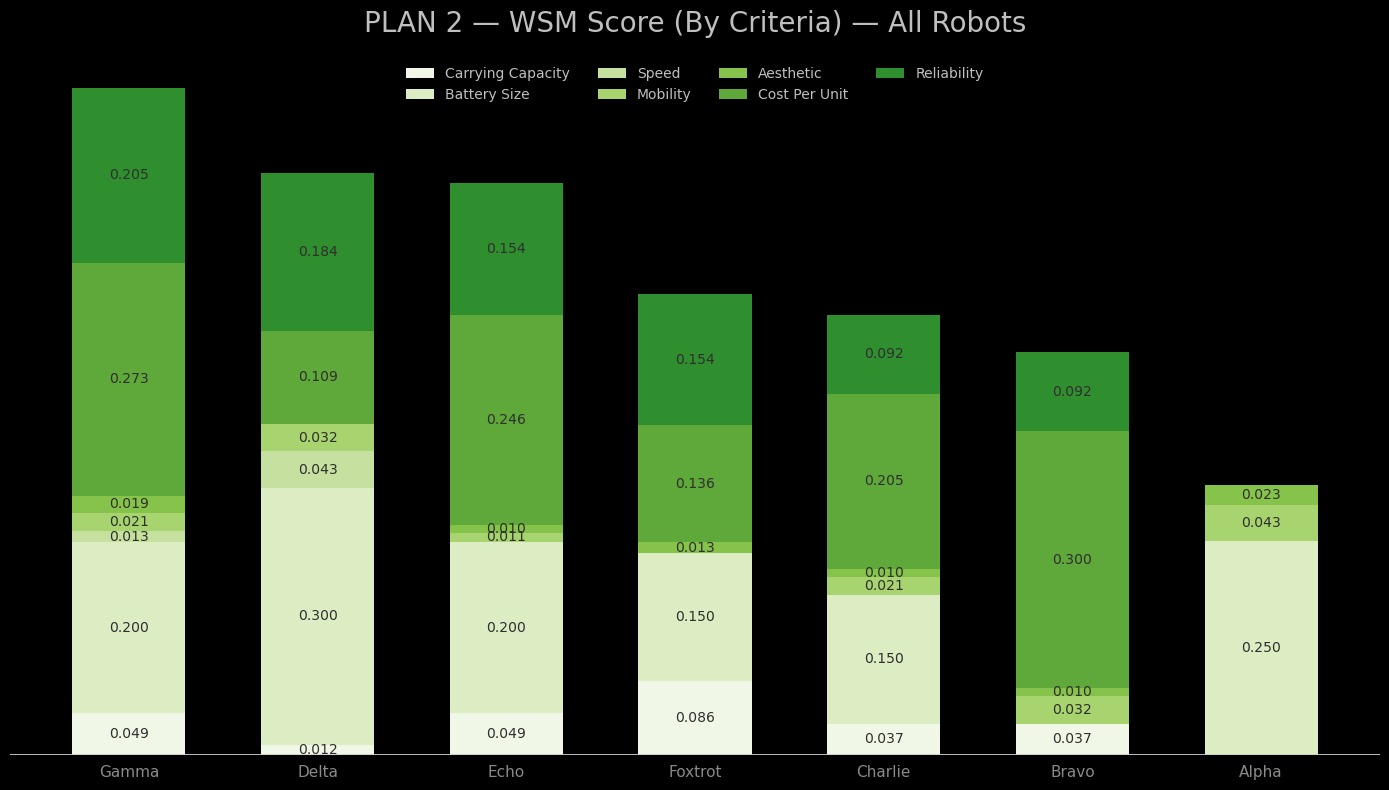

In [271]:
#Plotting the WSM contribution by criteria for all robots
def plot_wsm_all(norm_df, w, title):
    contrib = norm_df.mul(w, axis=1)                 # each cell = weight * normalised
    order = contrib.sum(axis=1).sort_values(ascending=False).index
    contrib = contrib.loc[order]

    # green-ish palette
    colors = [
    "#F1F7E7",  # very light
    "#DCECC3",
    "#C6E09F",
    "#A7D46F",
    "#86C34A",
    "#5FA83A",
    "#2F8F2F"   # dark
]

    fig, ax = plt.subplots(figsize=(14, 8), facecolor="black")
    ax.set_facecolor("black")

    x = np.arange(len(contrib))
    bottom = np.zeros(len(contrib))

    for i, c in enumerate(contrib.columns):
        vals = contrib[c].values
        ax.bar(x, vals, bottom=bottom, width=0.6, color=colors[i % len(colors)], label=c)

        # label segments (only if visible enough)
        for j, v in enumerate(vals):
            if v >= 0.001:
                ax.text(x[j], bottom[j] + v/2, f"{v:.3f}",
                        ha="center", va="center", fontsize=10, color="#2F2F2F")
        bottom += vals

    ax.set_title(title, color="#BFBFBF", fontsize=20, pad=16)

#Legend
    leg = ax.legend(ncol=4, loc="upper center", bbox_to_anchor=(0.5, 1),
                    frameon=False, fontsize=10)
    for t in leg.get_texts():
        t.set_color("#BFBFBF")

    ax.set_xticks(x)
    ax.set_xticklabels(contrib.index, rotation=0, color="#8A8A8A", fontsize=11)

    ax.tick_params(axis="y", left=False, labelleft=False)
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.axhline(0, color="#CFCFCF", linewidth=2)

    plt.tight_layout()
    plt.show()

plot_wsm_all(norm, w1, "PLAN 1 — WSM Score (By Criteria) — All Robots")
plot_wsm_all(norm, w2, "PLAN 2 — WSM Score (By Criteria) — All Robots")
